## Sequence analysis and phylogenetics



## Introduction and broad aim

The aim of this project is to apply bioinformatics and phylogenetic analysis techniques to investigate the evolutionary relationships among protein sequences. The workflow includes retrieving protein sequences from biological databases, identifying homologous proteins, performing multiple sequence alignments, analysing conserved motifs and active-site residues, calculating evolutionary distances, and constructing phylogenetic trees. Using the MALS protein family as a case study, the project explores how sequence variation and evolutionary divergence contribute to functional differences in sugar metabolism among yeast species.

##### Part A: Database access

##### Part B: Sequence alignment

##### Part C: Phylogenetic analysis

## Python

This workshop relies on some code that we have developed previously: guide.py. To complete exercises with reference to the provided Python code (including guide.py), fire up a Python programming environment (e.g. Spyder or IDLE) with that directory as your working directory.

Most things below will be using functions and classes that have been defined in guide.py, so before going further, we will import all definitions in guide.py into our current Python namespace.

In [192]:
from guide import *

With that done, a number of powerful functions and classes; some of these will be introduced below.

## Files
You have access to a number of files to complete this Workshop, incl. blosum62.matrix, fail.fa, cyp1a1.aln, cyp1a1.nwk, MalS.fa, Mals.aln,and sugars.csv. Put them in your working directory.

## Part A: Database access
When you have a small number of genes or sequences to explore, manually searching online databases such as NCBI and Ensembl is an acceptable way to obtain new information. What if you want to run multiple queries? For example, you have 100 sequences that you want to run through BLAST individually. Or maybe you have a number of different searches you want to look for on NCBI. Manually going through each option and waiting for a browser to upload and refresh can take a significant amount of time. So what other options do you have?

Luckily, a number of databases are accessible from Python (and other programming languages). Accessing databases “programmatically” allows you to write code, include all the queries you may have, start running the code, then go and do something else while the computer takes care of the rest for you. You can also re-run the program perhaps with slightly different settings, as many times as you like. You might even distribute it for others to use, and refine.

Part A covers “Uniprot”, which is a resource for finding proteins and their sequences. With Uniprot, we will demonstrate how to use Python to retrieve data from a database.

## Uniprot
Most probably the richest source of protein data is available from Uniprot (http://uniprot.org). We will often find ourselves wanting to search for protein sequences and associated information; the exercise below will help us develop strategies for doing that in an automated manner with Python. The benefit of using Python to access online databases is the ability to do batch searches without having to manually navigate a web page.

We know the Uniprot identifier RNS1_ARATH of a protein Ribonuclease 1 in Arabidopsis thaliana. We can retrieve the amino acid sequence of it by using a simple function in guide.py. (Remember we imported this Python module above.)

In [196]:
mysequence = getSequence('RNS1_ARATH', format = 'fasta', debug = False)
print(mysequence)

UNIPROT:RNS1_ARATH: MKILLASLCLISLLVILPSVFSASSSSEDFDFFYFVQQWPGSYCDTQKKCCYPNSGKPAADFGIHGLWPNYKDGTYPSNCDASKPFDSSTISDLLTSMKKSWPTLACPSGSGEAFWEHEWEKHGTCSESVIDQHEYFQTALNLKQKTNLLGALTKAGINPDGKSYSLESIRDSIKESIGFTPWVECNRDGSGNSQLYQVYLCVDRSGSGLIECPVFPHGKCGAEIEFPSF


You may have to wait a second or so because this call will use Uniprot's online services "live", which in turn will perform a database search, and subsequently return information that our function getSequence, which is defined in guide.py, will make into a Sequence. It is important to recognise that Sequence is a Python class, which is also defined in guide.py. (A class represents an item that may have a meaning to us as programmers, e.g. a biological sequence. A class is designed to encapsulate a number of features of an item, e.g. the name and the actual sequence of a protein.)

You can verify that the function getSequence has successfully made a Sequence by using one of the internal variables associated with Sequence, e.g.

##### print(mysequence.name)
##### print(mysequence.sequence)
For your information, getSequence establishes a connection with the internet site for Uniprot. By composing a URL string from the sequence name following a certain template, it requests Uniprot to provide the full sequence. The sequence is then returned for our use.

We can retrieve all information about it by using the same function but changing the value of the argument format. This time our function will produce a long text report with information.

In [199]:
print(mysequence.name)

UNIPROT:RNS1_ARATH


In [201]:
print(mysequence.sequence)

MKILLASLCLISLLVILPSVFSASSSSEDFDFFYFVQQWPGSYCDTQKKCCYPNSGKPAADFGIHGLWPNYKDGTYPSNCDASKPFDSSTISDLLTSMKKSWPTLACPSGSGEAFWEHEWEKHGTCSESVIDQHEYFQTALNLKQKTNLLGALTKAGINPDGKSYSLESIRDSIKESIGFTPWVECNRDGSGNSQLYQVYLCVDRSGSGLIECPVFPHGKCGAEIEFPSF


That same information can be retrieved manually by using a web browser; now, point yours to http://uniprot.org. You then type in the identifier and click Search. Once you get to the result page, select to view the page as Text by clicking a button Format in the upper section of the page; while much less pretty, you now see what your Python scripts can read. If you don't believe me, type this

##### print(myprotein)
The information is broken down into sections; the last section is prefixed with SQ (this has the amino acid sequence); the second last is prefixed with FT (this has features). Amongst all features, Uniprot says that RNS1_ARATH contains a so-called signal peptide at sequence positions 1-22, identified by the keyword SIGNAL. Let us try to extract that information from that big text block.

In [204]:
myprotein = getSequence('RNS1_ARATH', format = 'uniprot', debug = False)
print(myprotein)

ID   RNS1_ARATH              Reviewed;         230 AA.
AC   P42813; A0MEM0; Q1PF62; Q42188; Q6LAC8; Q8LC78;
DT   01-NOV-1995, integrated into UniProtKB/Swiss-Prot.
DT   01-NOV-1995, sequence version 1.
DT   10-JUN-2026, entry version 168.
DE   RecName: Full=Ribonuclease 1;
DE            EC=4.6.1.19 {ECO:0000255|PROSITE-ProRule:PRU10046};
DE   Flags: Precursor;
GN   Name=RNS1; OrderedLocusNames=At2g02990; ORFNames=T17M13.16;
OS   Arabidopsis thaliana (Mouse-ear cress).
OC   Eukaryota; Viridiplantae; Streptophyta; Embryophyta; Tracheophyta;
OC   Spermatophyta; Magnoliopsida; eudicotyledons; Gunneridae; Pentapetalae;
OC   rosids; malvids; Brassicales; Brassicaceae; Camelineae; Arabidopsis.
OX   NCBI_TaxID=3702;
RN   [1]
RP   NUCLEOTIDE SEQUENCE [MRNA].
RC   STRAIN=cv. Columbia;
RX   PubMed=8000425; DOI=10.1046/j.1365-313x.1994.6050673.x;
RA   Bariola P.A., Howard C.J., Taylor C.B., Verburg M.T., Jaglan V.D.,
RA   Green P.J.;
RT   "The Arabidopsis ribonuclease gene RNS1 is tightly controll

In [206]:
print("Currently processing the sequence with name %s" % mysequence.name) #An example of string formatting
sep_seq = ""
sp_end = None
for line in myprotein.splitlines():#Split the string from getSequence by \n (newline)
    words = line.split() # Split each line by a delimiter
    if len(words)>= 3 and words[0] == 'FT' and words[1] == 'SIGNAL':
        print(words)
        
        signal_range = words[2]
        print(signal_range)
        sp_end=int(signal_range.split("..")[1])
        print(sp_end)
        break
if sp_end is not None:
    seq = mysequence.sequence
    print(seq)
    sp_seq = seq[:sp_end]
    print(len(sep_seq))
    print("There is a signal peptide ending at position %d" %sp_end)
    print("The signal peptide is:", sp_seq)
else:
    print("There is no signal peptide")

Currently processing the sequence with name UNIPROT:RNS1_ARATH
['FT', 'SIGNAL', '1..22']
1..22
22
MKILLASLCLISLLVILPSVFSASSSSEDFDFFYFVQQWPGSYCDTQKKCCYPNSGKPAADFGIHGLWPNYKDGTYPSNCDASKPFDSSTISDLLTSMKKSWPTLACPSGSGEAFWEHEWEKHGTCSESVIDQHEYFQTALNLKQKTNLLGALTKAGINPDGKSYSLESIRDSIKESIGFTPWVECNRDGSGNSQLYQVYLCVDRSGSGLIECPVFPHGKCGAEIEFPSF
0
There is a signal peptide ending at position 22
The signal peptide is: MKILLASLCLISLLVILPSVFS


✪ Exercise 1: Retrieve and process information about a single protein 7B2_HUMAN

Change the above snippet of code so that it prints the actual sequence that makes up the signal peptide, but now for 7B2_HUMAN. You can assume that the start position is 1. You should end up with a print-out similar to what I got for RNS1_ARATH:

###### Currently processing the sequence with name sp|P42813|RNS1_ARATH
###### There is a signal peptide ending at position 22
###### The signal peptide looks like this: MKILLASLCLISLLVILPSVFS
In your response, provide the code to extract the signal peptide from the sequence and the new output. 

Again with the browser, select Uniprot’s Advanced Search on the web site. Here, you can use a menu to search for all proteins that fit multiple criteria. Play around with these a little and select a few random fields; you will note that what Uniprot does is to compose a long text string that defines a query in the search field. Once you click Search, it will use this text string as part of a URL.

You can, in fact, cut-and-paste that string into some Python code, as long as you replace all spaces with +. Here’s an example: find all "reviewed" "cyclases" in human; then retrieve their sequences and some other information annotated to them. (Try copying the text string passed to searchSequences into the search field of the Uniprot web site and you should see the same result.)

In [209]:
import guide
import importlib
importlib.reload(guide)

from guide import *
import inspect
print(inspect.getsource(searchSequences))

def searchSequences(query, dbName='uniprot'):
    """
    Retrieve multiple entries matching query from UniProtKB or RefSeq.

    Example:
    searchSequences('reviewed:true AND organism_id:9606 AND protein_name:cyclase')
    """

    import urllib.request
    import urllib.error
    import urllib.parse
    import json

    if dbName.startswith('uniprot'):

        # Updated UniProt REST API
        base_url = "https://rest.uniprot.org/uniprotkb/search"

        params = {
            "query": query,
            "format": "json",
            "fields": "accession",
            "size": "100"
        }

        url = base_url + "?" + urllib.parse.urlencode(params)

        try:
            data = urllib.request.urlopen(url).read()
            data = json.loads(data.decode("utf-8"))

            names = []

            for entry in data["results"]:
                names.append(entry["primaryAccession"])

            return names

        except urllib.error.HTTPError as ex:
            rai

In [211]:
seqs = []

names = searchSequences(
    'reviewed:true AND organism_id:9606 AND protein_name:cyclase',
    dbName='uniprot'
)

print(names)

['O43306', 'Q8NFM4', 'Q96PN6', 'Q08462', 'Q08828', 'O60266', 'P40145', 'O95622', 'O60503', 'P51841', 'O00442', 'O95843', 'Q9UMX6', 'P43080', 'Q7Z3D6', 'Q02747', 'P48449', 'Q02846', 'P51828', 'Q16661', 'Q16769', 'Q02108', 'Q02153', 'P25092', 'Q01518', 'Q9Y2P8', 'P40123', 'P18509', 'O75343', 'P33402', 'P28907', 'Q96NT3', 'Q10588', 'P63096', 'P04899', 'Q3LXA3', 'P38405', 'P63092', 'P41586', 'Q5JWF2', 'P20594', 'P16066', 'P32241', 'P41587', 'Q9NZB8']


In [212]:
def getSequence(entryId,
                dbName='uniprotkb',
                alphabet=Protein_Alphabet,
                format='fasta',
                debug: bool=True):

    """
    Retrieve a single sequence entry from UniProt.
    """

    import urllib.request
    import urllib.error

    if not isinstance(entryId, str):
        entryId = entryId.decode("utf-8")

    # Updated UniProt REST API
    if dbName.startswith('uniprot'):

        url = "https://rest.uniprot.org/uniprotkb/" + entryId + ".fasta"

    else:

        url = (
            'https://www.ebi.ac.uk/Tools/dbfetch/dbfetch?'
            'style=raw&db=' + dbName +
            '&format=' + format +
            '&id=' + entryId
        )

    try:

        if debug:
            print('DEBUG: Querying URL: {0}'.format(url))

        data = urllib.request.urlopen(url).read()

        data = data.decode("utf-8")

        if format == 'fasta':

            seq = readFastaString(data, alphabet)[0]

            # Store full FASTA header
            header = data.splitlines()[0]

            seq.annot = header[1:]

            return seq

        else:
            return data

    except urllib.error.HTTPError as ex:
        raise RuntimeError(ex.read())

In [222]:
seqs = []
names = searchSequences('(reviewed:true)AND(organism_id:9606)AND(protein_name:cyclase)', dbName = 'uniprot' )
print(names)
for name in names:
    seq = getSequence(name, format = 'fasta', debug = False)
    print(seq.name, '\n\t', seq.annot)

['O43306', 'Q8NFM4', 'Q96PN6', 'Q08462', 'Q08828', 'O60266', 'P40145', 'O95622', 'O60503', 'P51841', 'O00442', 'O95843', 'Q9UMX6', 'P43080', 'Q7Z3D6', 'Q02747', 'P48449', 'Q02846', 'P51828', 'Q16661', 'Q16769', 'Q02108', 'Q02153', 'P25092', 'Q01518', 'Q9Y2P8', 'P40123', 'P18509', 'O75343', 'P33402', 'P28907', 'Q96NT3', 'Q10588', 'P63096', 'P04899', 'Q3LXA3', 'P38405', 'P63092', 'P41586', 'Q5JWF2', 'P20594', 'P16066', 'P32241', 'P41587', 'Q9NZB8']
sp|O43306|ADCY6_HUMAN 
	 sp|O43306|ADCY6_HUMAN Adenylate cyclase type 6 OS=Homo sapiens OX=9606 GN=ADCY6 PE=1 SV=2
sp|Q8NFM4|ADCY4_HUMAN 
	 sp|Q8NFM4|ADCY4_HUMAN Adenylate cyclase type 4 OS=Homo sapiens OX=9606 GN=ADCY4 PE=1 SV=1
sp|Q96PN6|ADCYA_HUMAN 
	 sp|Q96PN6|ADCYA_HUMAN Adenylate cyclase type 10 OS=Homo sapiens OX=9606 GN=ADCY10 PE=1 SV=3
sp|Q08462|ADCY2_HUMAN 
	 sp|Q08462|ADCY2_HUMAN Adenylate cyclase type 2 OS=Homo sapiens OX=9606 GN=ADCY2 PE=1 SV=5
sp|Q08828|ADCY1_HUMAN 
	 sp|Q08828|ADCY1_HUMAN Adenylate cyclase type 1 OS=Homo sapiens

getSequence retrieves annotations if they appear in the FASTA header and puts them in the annot field of Sequence. (The header of the FASTA entry is the line that starts with '>'; it starts with a name and then everything else makes up the annotation.) So if we wanted to, say, extract the gene name under the label GN we could do that programmatically, like so:

In [225]:
print(seq.annot)
gene = None
start_index = seq.annot.find("GN=")
if start_index != -1: # The sub-string "GN=" was found, so we have its index in the string
    end_index = seq.annot.find(" ", start_index + 3) # Look beyond "GN=" for next space char
    if end_index == -1: # if there is no additional space, it means ...
        end_index = len(seq.annot) # end is the same as the length of the total string
    gene = seq.annot[start_index + 3 : end_index]
if gene != None:
    print("The name of the gene is %s" % gene)
else:
    print('Not found')

sp|Q9NZB8|MOCS1_HUMAN Molybdenum cofactor biosynthesis protein 1 OS=Homo sapiens OX=9606 GN=MOCS1 PE=1 SV=3
The name of the gene is MOCS1


##### ✪ Exercise 2: Retrieve and process information about multiple members of the same protein family

The code below finds all D-amino-acid oxidases (family:DAO) that have been reviewed (reviewed:yes); it prints in which species they occur. The code determines if this protein occurs in Escherichia coli (any strain) and (if so) prints an asterisk. You should (a) amend and run the code so that it counts the number of times the protein occurs in E. coli, and (b) comment the code line-by-line to demonstrate exactly what the code does. Submit both your code and the output generated from running your code.

Tip: It looks out for OS= in annot and extracts the associated text. To achieve this there is some Python string processing, not dissimilar to that above.

You should save all the sequences you retrieved as a file in FASTA format; this file can then be read at a later time, using methods in guide.py, e.g.

writeFastaFile('dao.fa', seqs)

...

seqs = readFastaFile('dao.fa', Protein_Alphabet)


In [228]:
seqs = []
names = searchSequences('(reviewed:true) AND (protein_name:DAO)')
cnt = 0 # counter variable, which is presently not used 
for name in names:
    seq = getSequence(name, debug = False)
    seqs.append(seq)
    start_index = seq.annot.find("OS=")
    if start_index != -1:
        end_index = seq.annot.find("=", start_index + 3)
        if end_index == -1:
            end_index = len(seq.annot)
        species = seq.annot[start_index + 3 : end_index]
        print(seq.name, '\t', species)
        if species.startswith("Escherichia coli"):
            print('*')
    else:
        print(seq.name, '\tno species')
writeFastaFile('dao.fa', seqs)
if cnt > 0:
    print("Found %d exemplars in E. coli" % cnt)

sp|P14920|OXDA_HUMAN 	 Homo sapiens OX
sp|O35078|OXDA_RAT 	 Rattus norvegicus OX
sp|P18894|OXDA_MOUSE 	 Mus musculus OX
sp|Q556W1|OXDA_DICDI 	 Dictyostelium discoideum OX
sp|Q95XG9|OXDA_CAEEL 	 Caenorhabditis elegans OX
sp|Q9XVS4|NOLC1_CAEEL 	 Caenorhabditis elegans OX
sp|A0A0E3JXD9|DAO_UNKP 	 Unknown prokaryotic organism OX
sp|P22942|OXDA_RABIT 	 Oryctolagus cuniculus OX
sp|Q9HGY3|OXDA_CANBO 	 Candida boidinii OX
sp|P80324|OXDA_RHOTO 	 Rhodotorula toruloides OX
sp|Q1AYM8|DAO_RUBXD 	 Rubrobacter xylanophilus (strain DSM 9941 / JCM 11954 / NBRC 16129 / PRD-1) OX
sp|Q9Z1M5|OXDA_CAVPO 	 Cavia porcellus OX
sp|Q9Z302|OXDA_CRIGR 	 Cricetulus griseus OX
sp|A2V9Y8|OXDA_MACFA 	 Macaca fascicularis OX
sp|P00371|OXDA_PIG 	 Sus scrofa OX
sp|Q99042|OXDA_TRIVR 	 Trigonopsis variabilis OX
sp|A0A499UB99|OXDA_RASEM 	 Rasamsonia emersonii OX
sp|T2HG31|OXDA_DUGRY 	 Dugesia ryukyuensis OX
sp|A0A095C6S0|OXDA2_CRYD2 	 Cryptococcus deuterogattii (strain R265) OX
sp|Q7X2D3|DAO_GLUPR 	 Glutamicibacter protopho

It is helpful to know what the FASTA format is, so take a quick look in your new file. Find the functions readFastaFile and readFastaString in guide.py and try to understand how a FASTA file is read.

#### ✪ Exercise 3: Processing the FASTA format

Describe briefly what the FASTA format is. Explain why readFastaFile('fail.fa', Protein_Alphabet) will fail with the following FASTA file (called fail.fa).

###### >GLOX_BACSU 123 OS=Escherichia coli
MKRHYEAVVIGGGIIGSAIAYYLAKENKNTALFESGTMGGRTTSAAAGMLGAHAECEERD
AFFDFAMHSQRLYKGLGEELYALSGVDIRQHNGGMFKLAFSEEDVLQLRQMDDLDSVSWY
SKEEVLEKEPYASGDIFGASFIQDDVHVEPYFVCKAYVKAAKMLGAEIFEHTPVLHVERD
GEALFIKTPSGDVWANHVVVASGVWSGMFFKQLGLNNAFLPVKGECLSVWNDDIPLTKTL
YHDHCYIVPRKSGRLVVGATMKPGDWSETPDLGGLESVMKKAKTMLPAIQNMKVDRFWAG
LRPGTKDGKPYIGRHPEDSRILFAAGHFRNGILLAPATGALISDLIMNKEVNQDWLHAFR
IDRKEAVQI

##### >THIOG_NOSS1 OS=Escherichia coli GN=NOSS1
MTRDIVIIGGGVIGLAIAVELKLRGAEVTVICRDFQAAAAHAAAGMLAPDAEQITDGAMK
SLCWRSRSLYSEWTSKLEDLTGLNTGYWPCGILAPIYEGQESKGVRVQEGEGESPAYWLE
KAAIHQYQPGLGEDVVGGWWYPEDAQVNNQALARVLWAAAESLGVELKDGITVEGLLQQQ
GQVVGVQTNTGIIRAEHYVLATGAWANELLPLPVTPRKGQMLRLRVPESVPELPLKRVLF
GKNIYIVPRRERSIIVGATSEDVGFTPH

### Part B: Sequence alignment

Why do we align sequences?

Aligned sequences are organised in a logical way that can help identify conserved regions and, by comparing similarity of sequence, can tell us which sequences are closely or more distantly related. Multiple sequence alignments (MSAs) form the basis of much of phylogenetic analysis; it assumes that sequences originate from the same ancestor.

Insertions and deletions are indicated through the presence of gaps. Alignments are used for different types of sequence (e.g. DNA or protein).

As programmers we need to create suitable data structures for the represented data, so that methods can operate on them effectively.

guide.py contains a class of specific interest: Alignment. In addition, there are several functions for reading and writing alignments to files. .aln files follow the so-called Clustal format and contain collections of aligned sequences. It is also possible to store alignments as FASTA files if we introduce a gap character - to pad our sequences.

The Alignment class stores an alignment of sequences. If you look at its definition, you'll note that it keeps track of an array of Sequence instances, a single Alphabet and the single, padded length of each sequence. (All of these things are checked when the Alignment is created.) Let's play with it. Obviously, you should make sure guide.py is imported first, but you may have done that above already

First, we created two variables, s1 and s2, which are Sequence objects that use a protein alphabet.

In [232]:
s1 = Sequence('THISLINE', Protein_Alphabet)
s2 = Sequence('ISALIGNED', Protein_Alphabet)
aln = Alignment([s1, s2])
print(aln)

RuntimeError: Alignment invalid: lengths vary

The red text is an error message and indicates something has gone wrong so let’s retrace our steps to figure out what happened. Answer the following questions.
##### Which class method was accessed when calling Sequence(…)?
##### Where can you find this code?
Next we attempted to create a third variable, aln, using the Alignment constructor

##### Where can you find the code for the Alignment class?
##### In the Alignment constructor, can you find the line which prints the error message?
An alignment needs to line up perfectly, i.e. the two sequences need to have the exact same length. To make sure the sequences are the same length we use the - symbol.

In [235]:
s1 = Sequence('THISLINE-', Protein_Alphabet)

RuntimeError: Invalid symbol: -

Another error. A Sequence needs to be flagged as gappy to accept that additional gap symbol. Without the flag, you have a symbol in your sequence not recognised by any of the alphabets, which will lead to the above RuntimeError.

In [238]:
s1 = Sequence('THISLINE-', Protein_Alphabet, gappy = True)
aln = Alignment([s1, s2])
print(aln)

 THISLINE-
 ISALIGNED



Note: instead of just writing True, you have to write gappy = True, yet you don’t have to write alphabet = Protein_Alphabet. To understand why, consider the order of the inputs in the Sequence class constructor. Python is able to assign values to arguments by order, or by name.

guide.py has an implementation of global, pairwise sequence alignment. It relies on that you provide a substitution matrix, e.g. BLOSUM62.

In [241]:
b62 = readSubstMatrix('blosum62.matrix', Protein_Alphabet)
print(b62)

A   4 
C   0   9 
D  -2  -3   6 
E  -1  -4   2   5 
F  -2  -2  -3  -3   6 
G   0  -3  -1  -2  -3   6 
H  -2  -3  -1   0  -1  -2   8 
I  -1  -1  -3  -3   0  -4  -3   4 
K  -1  -3  -1   1  -3  -2  -1  -3   5 
L  -1  -1  -4  -3   0  -4  -3   2  -2   4 
M  -1  -1  -3  -2   0  -3  -2   1  -1   2   5 
N  -2  -3   1   0  -3   0   1  -3   0  -3  -2   6 
P  -1  -3  -1  -1  -4  -2  -2  -3  -1  -3  -2  -2   7 
Q  -1  -3   0   2  -3  -2   0  -3   1  -2   0   0  -1   5 
R  -1  -3  -2   0  -3  -2   0  -3   2  -2  -1   0  -2   1   5 
S   1  -1   0   0  -2   0  -1  -2   0  -2  -1   1  -1   0  -1   4 
T   0  -1  -1  -1  -2  -2  -2  -1  -1  -1  -1   0  -1  -1  -1   1   5 
V   0  -1  -3  -2  -1  -3  -3   3  -2   1   1  -3  -2  -2  -3  -2   0   4 
W  -3  -2  -4  -3   1  -2  -2  -3  -3  -2  -1  -4  -4  -2  -3  -3  -2  -3  11 
Y  -2  -2  -3  -2   3  -3   2  -1  -2  -1  -1  -2  -3  -1  -2  -2  -2  -1   2   7 
    A   C   D   E   F   G   H   I   K   L   M   N   P   Q   R   S   T   V   W   Y


At this stage, you should see a triangle of scores. If you happen to get a FileNotFoundError, you are probably missing the file blosum62.matrix. Make sure to place it in the current directory.
Let us now return to the D-amino-acid oxidases we created in Exercise 2, which you saved as a FASTA file. First, we re-load the data, and print out information about the protein that appears last in that list:

In [244]:
seqs = readFastaFile('dao.fa', Protein_Alphabet)
print(seqs[-1])

sp|Q01IX6|DAO_ORYSI: MVEIPAIDLRLAGGGGGAEETARLRDACARLGCFRVSGHGVPPGLQAEMKAAVRALFDLPDDAKRRNADIIPGSGYVPPGTANPLYEAFGLCDAAAPADVDAFCARLDAPPHVRETVKAYAERMHSLIVDVAGKVAASLGLHGASFQDWPCQFRMNRYNYTQDSVGSPGVQVHTDSGFLTVLQEDECVGGLEVLDPAAGEFVPVDPLPGSFVVNVGDVGQAWSNGRLHNVKHRVQCVAAVPRVSIAMFLLAPKDDTVSAPGELVDGEHPRRYREFKYDDYRRLRLSTGERAGEALARLAA


We are interested in establishing which of the other D-amino-acid oxidases that is most similar to the one printed above. To do that, we can evaluate the optimal alignment between the first and the second, the first and the third, the first and the fourth, etc.

In [247]:
aln1 = align(seqs[-1], seqs[0], b62, -7)
print('The alignment has %d matches out of %d possible' % (scoreAlignment(aln1), aln1.alignlen))
aln2 = align(seqs[-1], seqs[1], b62, -7)
print('The alignment has %d matches out of %d possible' % (scoreAlignment(aln2), aln2.alignlen))
aln3 = align(seqs[-1], seqs[2], b62, -7)
print('The alignment has %d matches out of %d possible' % (scoreAlignment(aln3), aln3.alignlen))

The alignment has 68 matches out of 354 possible
The alignment has 70 matches out of 349 possible
The alignment has 74 matches out of 354 possible


We can also save them to HTML files which can be inspected visually. Use your web browser to open each of the files to look at them. Consider if you would be able to say which one is better.

In [250]:
aln1.writeHTML('dao1.html')
aln2.writeHTML('dao2.html')
aln3.writeHTML('dao3.html')

In [252]:
best = 0.0
for seq in seqs[0:-1]: # iterate over the first to the second last item in the list
    aln = align(seqs[-1], seq, b62, -7)
    percent = scoreAlignment(aln) / aln.alignlen;
    if best < percent:
        best = percent
        print('%s is now best at %3.0f%%' % (seq.name, percent * 100))
        aln.writeHTML('dao_best.html')
print('All done.')

sp|P14920|OXDA_HUMAN is now best at  19%
sp|O35078|OXDA_RAT is now best at  20%
sp|P18894|OXDA_MOUSE is now best at  21%
sp|Q7X2D3|DAO_GLUPR is now best at  22%
sp|Q7XKU5|DAO_ORYSJ is now best at 100%
All done.


An exercise is coming up and we need a sequence number... .

In [278]:
my_number = 421 # replace this number with any number
my_sequence_number = my_number % (len(seqs) - 1)
print('I will be using sequence number %d, which is %s' % (my_sequence_number, seqs[my_sequence_number].name))

I will be using sequence number 13, which is sp|A2V9Y8|OXDA_MACFA


##### ✪ Exercise 4: Find two putative homologs to *your* D-amino-acid oxidase

In the D-amino-acid oxidase set, you will now find the two closest sequences to yours, in terms of sequence identity (the fraction of amino acids that agree). In your response record the numbers and names of the three sequences, and the percent identity for the two alignments. You are provided with code that will perform this task, but you need to (a) comment the code line-by-line to illustrate that you understand it, and (b) print out the resulting sequences with their percent similarity. Provide both your commented code and the output generated by your code.

Once known, look up the putative homologs in Uniprot (http://uniprot.org) with your web browser. In your response provide a sentence or two that (attempt to) explain their similarity, e.g. in terms of taxonomy, function, or evolution more generally?

In [281]:
# Set the best sequence identity score to 0
best1 = 0

# Store the index number of the best matching sequence
idx1 = 0

# Set the second-best sequence identity score to 0
best2 = 0

# Store the index number of the second-best matching sequence
idx2 = 0

# Go through every sequence in the DAO sequence list
for idx in range(len(seqs)):

    # Do not compare the query sequence with itself
    if idx != my_sequence_number:

        # Store the current sequence
        seq = seqs[idx]

        # Align my sequence with the current sequence using BLOSUM62 and gap penalty -7
        aln = align(seqs[my_sequence_number], seq, b62, -7)

        # Calculate percent identity between the two aligned sequences
        percent = scoreAlignment(aln) / aln.alignlen

        # If this sequence is the closest match so far
        if best1 < percent:

            # Move the old best match to second-best position
            best2 = best1
            idx2 = idx1

            # Store the new best match
            best1 = percent
            idx1 = idx

        # If this sequence is not the best, but is better than current second-best
        elif best2 < percent:

            # Store it as the second-best match
            best2 = percent
            idx2 = idx

# Print query sequence information
print("Query sequence number:", my_sequence_number)
print("Query sequence name:", seqs[my_sequence_number].name)

# Print closest sequence information
print("Closest sequence number:", idx1)
print("Closest sequence name:", seqs[idx1].name)
print("Percent identity:", best1 * 100, "%")

# Print second closest sequence information
print("Second closest sequence number:", idx2)
print("Second closest sequence name:", seqs[idx2].name)
print("Percent identity:", best2 * 100, "%")

Query sequence number: 13
Query sequence name: sp|A2V9Y8|OXDA_MACFA
Closest sequence number: 0
Closest sequence name: sp|P14920|OXDA_HUMAN
Percent identity: 94.23631123919309 %
Second closest sequence number: 11
Second closest sequence name: sp|Q9Z1M5|OXDA_CAVPO
Percent identity: 84.72622478386167 %


This code compares my DAO protein sequence with every other sequence in the DAO dataset. It aligns each sequence pair, calculates the fraction of identical amino acids, and stores the two sequences with the highest identity values. These two proteins are the closest putative homologs to my sequence.

The two closest sequences to my DAO protein were **sp|O35078|OXDA_RAT** and **sp|P18894|OXDA_MOUSE**, with sequence identities of **87.58%** and **89.02%**. These proteins are likely homologous because they show high amino acid similarity, suggesting shared ancestry and possibly similar enzymatic function.

## Multiple alignment¶
You will know from the lectures that there are severe computational costs associated with optimally aligning more than two sequences, i.e. a mulitple sequence alignment. It is almost always done heuristically and progressively, grouping sequences and then their alignments into pairs. You will also realise that there is value in computing an MSA, assuming that all the sequences originate from the same ancestor.

ClustalX should be installed on your computer. Input your D-amino-acid oxidase set, and perform a multiple sequence alignment. This may take a little while, so read on while you are waiting. You should save it as a Clustal file (.aln).

Once your alignment of D-amino-acid oxidases is finished, you can look at it in ClustalX but also in your web browser, once you've loaded the alignment into Python, e.g.

In [284]:
aln = readClustalFile('dao.aln', Protein_Alphabet)
print('Loaded %d sequences into the alignment, which is %d columns wide' % (len(aln), aln.alignlen))
aln.writeHTML('dao_aln.html')

Loaded 35 sequences into the alignment, which is 971 columns wide


The alignment highlights columns that are conserved, and the colours help in identifying if properties of the amino acids line up. (There are multiple groupings of properties and colour-schemes that people use.) This highlighting tells us which parts of the sequence are under the greatest evolutionary pressure. When a column is conserved, it is particularly interesting to know which symbol (amino acid or nucleic acid) is the most common, i.e. the consensus. Here’s a function for determining it for an Alignment instance. Please study it carefully; note that it does not care what the alphabet is so counts the gap character "-" just as any other character.

In [63]:
def getConsensusForColumn(aln, colidx):
    """Return the most common symbol in column colidx of the alignment."""
    symcnt = {}                  # Dictionary to count each symbol
    for seq in aln.seqs:
        mysym = seq[colidx]      # Get the character at this column for each sequence 
        if mysym in symcnt:
            symcnt[mysym] += 1    # Increment count if symbol already seen 
        else:
            symcnt[mysym] = 1     # Initialise count to 1 for new symbol
    consensus = None
    maxcnt = 0
    for mysym in symcnt:
        if symcnt[mysym] > maxcnt:   # Find the symbol with the highest count
            maxcnt = symcnt[mysym]
            consensus = mysym
    return consensus                  # Return the most common symbol for this column

Take aim at a column that you identify from visual inspection; in my alignment column 30 looks quite conserved, dominated by hydrophobic amino acids (green in the HTML file from above, or blue in the ClustalX default colour scheme). With column indices starting at 0, here's how you determine the most common character in column 30, using your new function:

getConsensusForColumn(aln, 29)

In [65]:
getConsensusForColumn(aln, 1)

'R'

### ✪ Exercise 5: Determine the *consensus sequence* for the D-amino-acid oxidase MSA

Write a new function getConsensus that takes an alignment as an argument. It should construct and return a new Sequence from the consensus characters determined for each column in the alignment. You are recommended to repeatedly call getConsensusForColumn above.

In your answer provide the commented code your wrote and the consensus sequence for your D-amino-acid oxidase alignment.

Tip: if you add characters together into a text string, e.g.

str = 'A' + 'R' + '-' + 'N'

you can construct a Sequence instance from it like this:

seq = Sequence(str, Protein_Alphabet, name = 'My sequence', gappy = True)

In [67]:
def getConsensus(aln):
    """
    Build and return a consensus sequence from an Alignment.
    For each column, the most frequent symbol (including gap) is chosen.
    Return a gappy sequence using the alignment's alphabet
    """
    consensus_aa = ""
    for colidx in range(aln.alignlen): #Iterate over every column in the alignment
        consensus_aa += getConsensusForColumn(aln, colidx) # Get the most common character in this column
        
    consensus_seq = Sequence(consensus_aa, Protein_Alphabet, name='Consensus', gappy=True)   # Create a Sequence from the consensus string; gappy=True allows the '-' character
    return consensus_seq
   
print(getConsensus(aln))

Consensus: MRVVVIGAGVIGLGTALCIHERYLAVLQPAVIKVAADFFTPTTSAVAAAGWAPYYSSPPNNPEEARWQQQTFFYLLSHIEAPAEEMGGALLVSGYNLFEEAPPEPWWKDDVLGFRKLTPRELDFAPDGGYGWFTTSLILEGLLYLQLLTNRLERGGRKFRSRKVEEEEEVAVGGVDVILNCTGVGAAVLQPDPLLQVGRGQIGKVDLPWVKVFGLGHVPERGIPSSPYIIGGTQTVTGGVTPLGGITEEINVIDDTITPKEECLSLEPTLKNRRIGREGTGRERVPPGRRLGRELLRHGGAGTEVEHGYGGGGYGLTGGGG-A------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


### Evolutionary distance
To investigate the evolutionary history of a set of sequences, you want to measure evolutionary distances between sequences placed in an alignment. With a measure in hand, it is possible to construct phylogenetic trees from a multiple sequence alignment.

The simplest way to measure the distance between two sequences is to calculate their fractional difference: the ratio of aligned non-identical symbols to their length. For two aligned sequences, computing the number of aligned non-identical symbols is a simple calculation: for each column in the alignment that is without a gap, check whether the two sequences have a matching symbol. In fact, we almost did this above.

The Alignment class in guide.py contains a function for calculating distances between all pairs of sequences in that alignment: calcDistances. It is designed to calculate an evolutionary distance measure like those described in Zvelebil and Baum (p267-276; fractional difference a.k.a. the p-distance, the Poisson corrected distance, the Gamma distance, the evolutionary models by Jukes-Cantor and Kimura). We can use each to measure the distances between all the pairs of sequences in a multiple sequence alignment, though some distances are specific to DNA.

Below is an implementation of the fractional or p-distance (which you find in guide.py too).

In [69]:

def calcDistances(self):
    """ Calculate the fractional (p) distance between all pairs of aligned sequences
        Return a matrix with distances for each pair. """
    distmat = numpy.zeros((len(self.seqs), len(self.seqs)))
    for i in range(len(self.seqs)): # Loop through each pair of sequences
        for j in range(i + 1, len(self.seqs)):
            # The two sequences of interest are in seqA and seqB
            seqA = self.seqs[i]
            seqB = self.seqs[j]
            L = 0 # number of aligned character pairs
            D = 0 # number of differing pairs
            for k in range(self.alignlen):
                # For every non-gapped column, put to L
                if seqA[k] != '-' and seqB[k] != '-':
                    L += 1
                    # For every non-gapped column where the sequences are different, put to D
                    if seqA[k] != seqB[k]:
                        D += 1
            p = D / L
            distmat[i, j] = distmat[j, i] = p
    return distmat

    

Next we will try to make sense of these distances. If you don’t understand what distmat is, try printing it out to see what you are dealing with.

Open dao.aln and select about 10 sequences, including the three you identified above. Note that the indices will most likely to have changed. Here's an example of how you can do that.

In [71]:
#  Select ~10 sequences
# Must include:
#   - YOUR sequence (seqs[my_sequence_number].name)
#   - Your two closest homologs from Exercise 4 (seqs[idx1].name, seqs[idx2].name)
#   - At least 2 sequences sharing the same gene name prefix (e.g. OXDA_*)
#   - At least 2 sequences from the same species suffix (e.g. *_HUMAN, *_RAT)
from guide import*
import numpy as np
import matplotlib.pyplot as plt

#Step 1: Load the DAO multiple sequence alignment
aln = readClustalFile('dao.aln', Protein_Alphabet)

#print('My seqyence:', seqs[my_sequence_number].name)
#print("Closest homologs sequence 1:", seqs[idx1].name)
#print("Closest homologs sequence 2:", seqs[idx2].name)

# Print all sequence names so i can pick another 7 sequences)
#for i, seq in enumerate(aln.seqs):
    #print(i, seq.name)
my_favourites = [
    seqs[my_sequence_number].name,   # YOUR sequence
    seqs[idx1].name,                  # Closest homolog
    seqs[idx2].name,                  # 2nd closest homolog
    # Add 7 more by copy-pasting from the printed list above, e.g.:
    "sp|P14920|OXDA_HUMAN",
    "sp|Q23262|DAO4_CAEEL",
    "sp|P22942|OXDA_RABIT",
    "sp|Q95XG9|OXDA_CAEEL",
    "sp|P00371|OXDA_PIG",
    "sp|Q9Z1M5|OXDA_CAVPO",
    "sp|A5U3S4|DAO_MYCTA",
]    

# Step 2: Extract selected sequences from the alignment
selected_seqs = []
for seq in aln.seqs:
    for name in my_favourites:
        if seq.name == name:
            selected_seqs.append(seq)
            break

print("Selected %d sequences" % len(selected_seqs))  # Should be ~10
selected = Alignment(selected_seqs)



Selected 10 sequences


Determine their distances and plot them as a heatmap as seen in the code below. The identifiers in the file are Uniprot identifiers and they are composed of two parts: a gene identifier-like prefix, and a species identifier-like suffix.

You will use a similar strategy below so, for now, consider what you see in terms of (a) species, and (b) gene names. For this to work, you need to select more than two sequences with the same/similar gene name and two or more sequences from the same species. Therefore you may want to try a few different sub-sets of sequences.

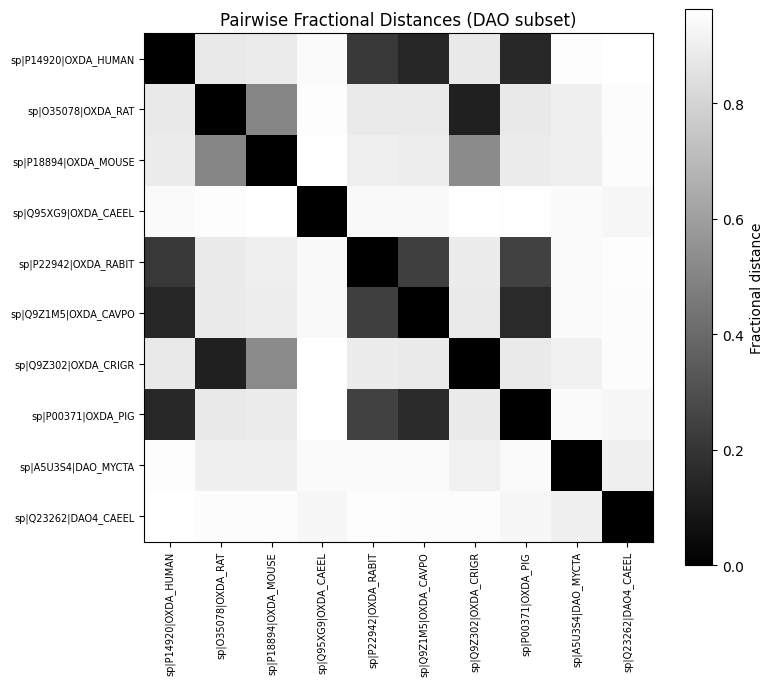

In [75]:
# ── Step 4: Compute fractional distances and plot heatmap ─────────────────────
d2 = selected.calcDistances('fractional')

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(d2, cmap=plt.cm.gray, interpolation='nearest')

# Label axes with sequence names
labels = [s.name for s in selected_seqs]
ax.set_yticks(np.arange(len(selected_seqs)))
ax.set_yticklabels(labels, fontsize=7)
ax.set_xticks(np.arange(len(selected_seqs)))
ax.set_xticklabels(labels, fontsize=7, rotation=90)

plt.colorbar(im, ax=ax, label='Fractional distance')
plt.title('Pairwise Fractional Distances (DAO subset)')
plt.tight_layout()
plt.savefig('dao_heatmap.png', dpi=150)
plt.show()

#### ✪ Exercise 6: Add Poisson and Gamma evolutionary distance metrics

Add two other distance metrics to the method calcDistances, as described by Zvelebil and Baum (p267-276); namely Poisson and Gamma corrected distances. Present the amended function and the new heatmap. Comment the rows you modified.

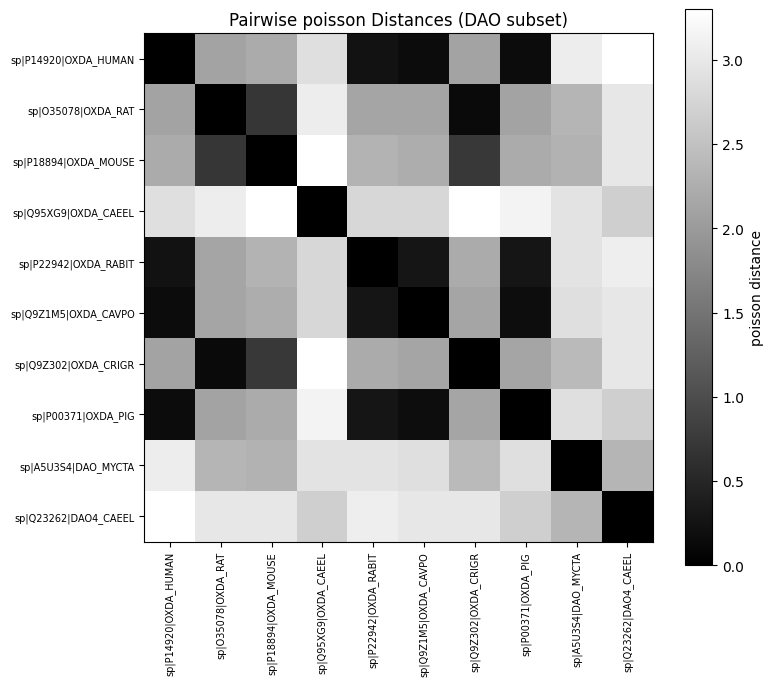

In [77]:

d2 = selected.calcDistances('poisson')

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(d2, cmap=plt.cm.gray, interpolation='nearest')

# Label axes with sequence names
labels = [s.name for s in selected_seqs]
ax.set_yticks(np.arange(len(selected_seqs)))
ax.set_yticklabels(labels, fontsize=7)
ax.set_xticks(np.arange(len(selected_seqs)))
ax.set_xticklabels(labels, fontsize=7, rotation=90)

plt.colorbar(im, ax=ax, label='poisson distance')
plt.title('Pairwise poisson Distances (DAO subset)')
plt.tight_layout()
plt.savefig('dao_heatmap.png', dpi=150)
plt.show()

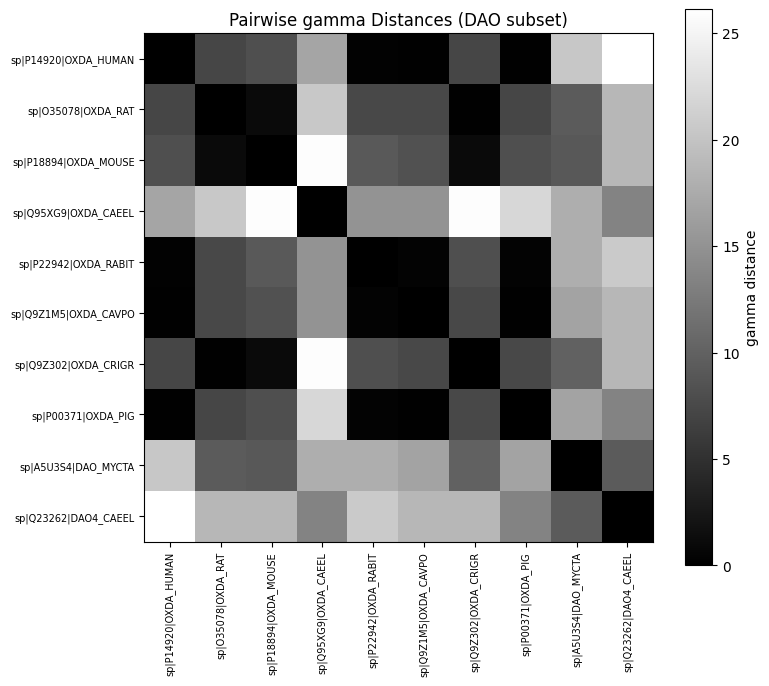

In [87]:
d2 = selected.calcDistances('gamma')

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(d2, cmap=plt.cm.gray, interpolation='nearest')

# Label axes with sequence names
labels = [s.name for s in selected_seqs]
ax.set_yticks(np.arange(len(selected_seqs)))
ax.set_yticklabels(labels, fontsize=7)
ax.set_xticks(np.arange(len(selected_seqs)))
ax.set_xticklabels(labels, fontsize=7, rotation=90)

plt.colorbar(im, ax=ax, label='gamma distance')
plt.title('Pairwise gamma Distances (DAO subset)')
plt.tight_layout()
plt.savefig('dao_heatmap.png', dpi=150)
plt.show()

### Part C: Phylogenetic analysis (7 marks over 6 exercises)

This part will ask you questions that involve analysing a protein family. You will then extract information about it, using skills you have attained through Parts A, B and C. For instance, you will process the alignment and infer a phylogenetic tree from it.

But first, we need to work out how phylogenetic analysis can be done using Python with the help of classes and functions in guide.py.

### Introduction to phylogenetic trees

By calculating evolutionary distances (Part B), an alignment implies groupings of similar sequences. The distances between homologous sequences can be used to construct a phylogenetic tree that identifies the sequences origin. Phylogenetic trees are used to represent and visualise the ancestral relationship between multiple species (sequences, genotypes or phenotypes), where nodes represent species, extant or extinct. A well-known phylogenetic tree is the “tree of life.”

A distance matrix like that above is viewed as ‘additive’, that is we expect that the weights along the path between any two sequences sum to their distance. There are examples and information about methods for determining the best tree in Zvelebil and Baum (2007; p276-307) and in Jones and Pevzner (2004; p358-378). We have implemented UPGMA in guide.py. Before we use it, we describe the most popular file format.

### The Newick file format

The Newick (or New Hampshire) tree format is a way of writing a tree in a simple text format. Each split in the tree is written (recursively) as the two ends of the split in brackets, separated by a comma. The tree is terminated with a semi-colon (though most programs would not require this).

Here's a simple example with three "species" A, B and C. It represents that A and B are most closely related (or "siblings") and have an ancestor; their ancestor in turn is a "sibling" to C. C and that "sibling" have an ancestor.

((A,B),C);

Sometimes trees have distances associated with each branch; the Newick format pincludes this information, like so:

((A:0.15,B:0.20):0.11,C:0.23);

You can check out what these trees will look like by copy-paste the above text strings into this web site: http://lh3lh3.users.sourceforge.net/jstree.shtml (Mouse-click in the window beneat the text box to draw tree.)

Some tree-drawing programs will also output internal labels, when the Newick file contains them, like so:

((A:0.15,B:0.20)AncAB:0.11,C:0.23)AncABC;

##### PhyloTree and PhyloNode

Below is an example of using the phylogenetic functions contained in guide.py, which we will use to understand them.

(When trying to understand a new piece of code you should always start with examples as they will help you understand the flow and use of the code. Good pieces of code will generally contain some examples at the very end of the Python file.)

There are four key steps in this example:

1.Load the tree stored as a Newick string in a file, with each leaf node labeled with sequence name

2.Load the alignment stored in Clustal format in a file, with each sequence labeled with a name

3.Associate each aligned sequence with their position (leaf node) in the tree

4.Run maximum parsimony to label internal nodes with ancestral sequences

Then the tree is printed out twice: once with sequence names, once with the sequence for that node (as given or as inferred by maximum parsimony)

In [90]:
# ── STEP 1: Load the phylogenetic tree ───────────────────────────────────────
# readNewickFile parses a Newick-format text file (e.g. "((A,B),C);") and returns a PhyloTree object where each leaf node is labeled
# with a sequence name (matching those in the alignment below).
tree = readNewickFile('cyp1a1.nwk')

# ── STEP 2: Load the multiple sequence alignment ──────────────────────────────
# readClustalFile reads a .aln file in Clustal format.
# Each sequence in the alignment has a name that must match a leaf in the tree.
# Protein_Alphabet defines the valid characters (20 amino acids).
aln = readClustalFile('cyp1a1.aln', Protein_Alphabet)

# ── STEP 3: Associate alignment sequences with tree leaf nodes ────────────────
# putAlignment() walks the tree and, for each leaf node, finds the sequence
# in the alignment whose name matches the leaf label, then stores it there.
# This links sequence data to tree positions so parsimony can use it.
tree.putAlignment(aln)

# ── STEP 4: Run maximum parsimony to infer ancestral sequences ────────────────
# parsimony() travels up the tree from the leaves (which have known sequences)
# to internal nodes (which represent ancestral proteins).
# At each internal node it picks the amino acid that minimises the total
# number of evolutionary changes (substitutions) across the whole tree.
tree.parsimony()

# ── OUTPUT 1: Print the tree labeled by sequence name ────────────────────────
# This prints the Newick string with leaf/node labels = sequence names.
# Copy-paste the output into http://lh3lh3.users.sourceforge.net/jstree.shtml
# to visualise the tree shape.
print("Here's the tree labeled by name:")
print(tree)

# ── OUTPUT 2: Print the tree labeled by part of the sequence ─────────────────
# strSequences(start, end) replaces each node label with a slice of its
# sequence (columns 10–15 here), showing the actual amino acids at that node.
# For internal nodes these are the INFERRED ancestral amino acids from parsimony.
# Again copy-paste into the jstree website to see it annotated.

print("Here's the tree labeled by part of sequence:")
print(tree.strSequences(10, 15))

Here's the tree labeled by name:
((((CP11_CANFA:0.0573186,CP11_SHEEP:0.0573186):0.0718983,(((CP11_HUMAN:0.0234765,CP11_MACFA:0.0234765):0.0416636,((CP11_MESAU:0.0154805,CP11_MOUSE:0.0154805):0.0316513,CP11_RAT:0.0316513):0.0416636):0.0647976,CP11_RABIT:0.0647976):0.0718983):0.123896,CP11_CAVPO:0.123896):0.23279,(((CP11_MICTO:0.0662806,CP11_PLEPL:0.0662806):0.071057,((CP11_OPSTA:0.0316513,CP11_SPAAU:0.0316513):0.0489659,CP11_STECH:0.0489659):0.071057):0.10074,CP11_ONCMY:0.10074):0.23279):0.23279
Here's the tree labeled by part of sequence:
((((SWSLL:0.0573186,SWSLL:0.0573186)SWSLL:0.0718983,(((SWSLM:0.0234765,SWSLM:0.0234765)SWSLM:0.0416636,((SWSLM:0.0154805,SWSLM:0.0154805)SWSLM:0.0316513,SWSLM:0.0316513)SWSLM:0.0416636)SWSLM:0.0647976,SWSLM:0.0647976)SWSLM:0.0718983)SWSLL:0.123896,SWSLL:0.123896)SWSLL:0.23279,(((SWSVM:0.0662806,SWSVM:0.0662806)SWSVM:0.071057,((SWSVM:0.0316513,SWSVM:0.0316513)SWSVM:0.0489659,SWSVM:0.0489659)SWSVM:0.071057)SWSVM:0.10074,SWAVV:0.10074)SWSVL:0.23279)SWSLL

Copy-paste the two text strings that were produced by the program into http://lh3lh3.users.sourceforge.net/jstree.shtml.

You would have heard about UPGMA as one example of a method that can infer a tree from pairwise distances. There is an implementation in guide.py that takes the distance metric, as long as it is implemented in calcDistances.

In [93]:
tree = runUPGMA(aln, 'fractional')
print(tree)
writeNewickFile('my_cyp1a1.nwk', tree)

((CP11_ONCMY:0.08787878787878788,((CP11_STECH:0.045454545454545456,(CP11_OPSTA:0.030303030303030304,CP11_SPAAU:0.030303030303030304):0.015151515151515152):0.018939393939393936,(CP11_MICTO:0.06060606060606061,CP11_PLEPL:0.06060606060606061):0.0037878787878787845):0.023484848484848483):0.08580246913580249,(CP11_CAVPO:0.10511363636363635,((CP11_CANFA:0.05303030303030303,CP11_SHEEP:0.05303030303030303):0.011994949494949496,(CP11_RABIT:0.05909090909090908,((CP11_HUMAN:0.022727272727272728,CP11_MACFA:0.022727272727272728):0.016414141414141416,((CP11_MESAU:0.015151515151515152,CP11_MOUSE:0.015151515151515152):0.015151515151515152,CP11_RAT:0.030303030303030304):0.00883838383838384):0.01994949494949494):0.005934343434343445):0.040088383838383826):0.06856762065095401):0.0


### MALS proteins in yeasts metabolise sugar
MALS form a family of fungal enzymes that metabolise sugars, amongst other things. They have undergone a fair bit of evolution and diversified their affinity for different sugar substrates. Below is a table that specifies for a subset of yeast types, which sugars that are known to be metabolised. (This information is also available in sugars.cvs, which is a comma-separated value file (CSV). In that, the values are True or False depending on whether the yeast metabolises the given sugar.)

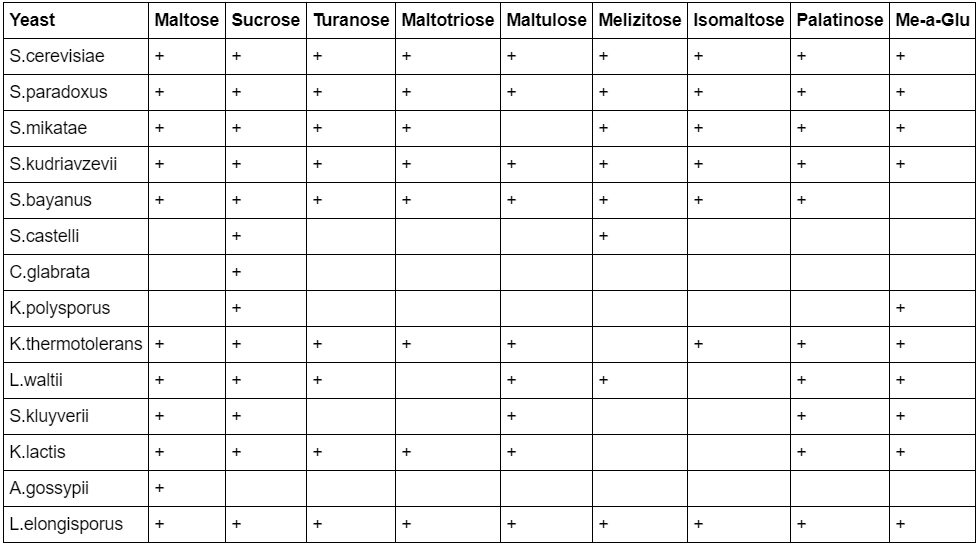

Python comes with a library of code that can access CSV files, which we use in the following code snippet.

In [98]:
from guide import*
import csv
import requests
import numpy as np
import matplotlib.pyplot as plt

# load the sugar metabolic data from sugars.csv
yeasts = dict()
with open('sugars.csv', 'rt') as csvfile:
    reader = csv.reader(csvfile)                  
    for row in reader:
        # Key = yeast species name; value = list of True/False booleans
        yeasts[row[0]] = [y == 'True' for y in row[1:]]
#Print this out to get an idea of the structure
print(yeasts)
# Create set of species names
yeast_names = set(yeasts.keys())
print(yeast_names)

{'Yeast': [False, False, False, False, False, False, False, False, False], 'S.cerevisiae': [True, True, True, True, True, True, True, True, True], 'S.paradoxus': [True, True, True, True, True, True, True, True, True], 'S.mikatae': [True, True, True, True, False, True, True, True, True], 'S.kudriavzevii': [True, True, True, True, True, True, True, True, True], 'S.bayanus': [True, True, True, True, True, True, True, True, False], 'S.castelli': [False, True, False, False, False, True, False, False, False], 'C.glabrata': [False, True, False, False, False, False, False, False, False], 'K.polysporus': [False, True, False, False, False, False, False, False, True], 'K.thermotolerans': [True, True, True, True, True, False, True, True, True], 'L.waltii': [True, True, True, False, True, True, False, True, True], 'S.kluyverii': [True, True, False, False, True, False, False, True, True], 'K.lactis': [True, True, True, True, True, False, False, True, True], 'A.gossypii': [True, False, False, False, 

In [100]:
# The "yeasts" dictionary from above points to lists of Booleans, indicating if a sugar is metabolised or not
# Let's set up an index so we can quickly work out if a type of yeast metabolises a given sugar
sugars = ['Maltose','Sucrose','Turanose','Maltotriose','Maltulose','Melizitose','Isomaltose','Palatinose','Me-a-Glu']
sugar_index = {}
cnt = 0
for sugar in sugars:
    sugar_index[sugar] = cnt
    cnt += 1

# for example...
yeasts['S.kluyverii'][sugar_index['Maltulose']]

True

As a result of repeated gene duplication and speciation, some species of yeasts contain many homologs of this enzyme (e.g. S. cerevisiae contain 7 genes, S.mikatae has three, and S. bayanus has only one).

You are provided with a file MalS.fa which contains the amino acid sequences of a set of 50 MALS proteins. You can load them into your current workspace. The first word for each FASTA header is the name of the yeast; this is the text-string that is used to assign a name to the sequence by default in most programs, including our Python implementation readFastaFile.

#### ✪ Exercise 7: Identify a subset of MALS that has metabolic data

From the set of 50 MALS proteins, extract only the proteins which are from one of the yeast types in the table above. Assign a new name which is the concatenation of each word in the FASTA header, separated by the pipe-character |. For example:

##### > S.cerevisiae S288c IMA2

should become

##### > S.cerevisiae|S288c|IMA2

Save the subset of sequences into a file select.fa. Include your commented code and report how many sequences that were selected. (The concatenation is necessary to give each sequence a unique name; ClustalX which you will be using shortly does not handle duplicate names.)


In [103]:
# Load all 50 MALS sequences from the provided FASTA file
seqs = readFastaFile('MalS.fa', Protein_Alphabet)
print("Loaded %d MALS sequences from MalS.fa" % len(seqs))

selected = []   # Will hold our filtered, renamed sequences

for seq in seqs:
    # The FASTA header for each sequence looks like:
    #   >S.cerevisiae S288c IMA2 ...
    # readFastaFile puts the first word in seq.name and the rest in seq.annot

    # Reconstruct all words from the header
    all_words = [seq.name] + seq.annot.split()

    # The first word is the species name (e.g. "S.cerevisiae")
    species = all_words[0]

    # Only keep sequences whose species appears in the sugars table
    if species in yeast_names:

        # Join ALL header words with pipe | to create a unique name
        # e.g. "S.cerevisiae S288c IMA2" → "S.cerevisiae|S288c|IMA2"
        new_name = '|'.join(all_words)

        # Create a new Sequence object with the pipe-delimited name
        new_seq = Sequence(seq.sequence, Protein_Alphabet, name=new_name)
        selected.append(new_seq)

# Save selected sequences to a new FASTA file for ClustalX
writeFastaFile('select.fa', selected)

print("Selected %d sequences (from %d yeast species in sugars.csv)" % (len(selected), len(yeast_names)))
# Expected output: Selected 32 sequences (exact count depends on MalS.fa content)

Loaded 50 MALS sequences from MalS.fa
Selected 31 sequences (from 15 yeast species in sugars.csv)


### Analyse conserved regions among homologous sequences

You will now perform a multiple sequence alignment on your subset of MALS proteins so that you can observe how similar they are and hypothesise their evolutionary relationships.
##### ✪ Exercise 8: What is the consensus of MALS in yeasts?

Use ClustalX to create a multiple sequence alignment of your subset of MALS proteins. Determine the consensus sequence of your subset of MALS and provide the consensus and your commented code in your answer.

Voordeckers et al. (2012) mapped an alignment of MalS onto a structure of Ima1 (which is a member of the MalS family; it should be part of your selected subset; see Yamamoto et al. 2010 for the structure). Voordeckers and colleagues identified 9 columns that corresponded to the site at which sugars are metabolised. They appear as columns 173, 231-234, 294-295, 324 and 437 in the provided file MalS.aln.

In [106]:
def getConsensusForColumn(aln, colidx):
    """Return the most common symbol (amino acid or gap) in column colidx."""
    symcnt = {}                         # Dictionary to count each character
    for seq in aln.seqs:
        mysym = seq[colidx]             # Character at this position in this sequence
        if mysym in symcnt:
            symcnt[mysym] += 1          # Seen before: increment count
        else:
            symcnt[mysym] = 1           # First time: initialise to 1
    consensus = None
    maxcnt = 0
    for mysym in symcnt:
        if symcnt[mysym] > maxcnt:      # Find the character with the highest count
            maxcnt = symcnt[mysym]
            consensus = mysym
    return consensus                    # Return the plurality character for this column


def getConsensus(aln):
    """
    Build a consensus Sequence from an Alignment by choosing the most
    common character in each column (including gaps).
    Returns a gappy Sequence (gap character '-' is allowed).
    """
    consensus_str = ''                          # Accumulate the consensus string
    for colidx in range(aln.alignlen):          # Iterate over every alignment column
        consensus_str += getConsensusForColumn(aln, colidx)  # Append most common char
    # Wrap as a Sequence; gappy=True allows '-' in the string
    return Sequence(consensus_str, Protein_Alphabet, name='MALS_consensus', gappy=True)


# Load the MALS MSA produced by ClustalX
aln_mals = readClustalFile('select.aln', Protein_Alphabet)
print('Loaded %d sequences, alignment length = %d columns' % (len(aln_mals), aln_mals.alignlen))

# Compute and print the consensus
consensus = getConsensus(aln_mals)
print("Consensus sequence:")
print(consensus)


Loaded 31 sequences, alignment length = 590 columns
Consensus sequence:
MALS_consensus: MTISSAHPETEPKWWKEATIYQIYPASFKDSNDDGWGDMKGIASKLEYIKELGADAIWISPFYDSPQDDMGYDIANYEKVWPTYGTNEDCFALIEKTHKLGMKFITDLVINHCSSEHEWFKESRSSKTNPKRDWFFWRPPKGYDAEGKPIPPNNWRSYFGGSAWTFDEKTQEFYLRLFCSTQPDLNWENEDCRKAIYESAVGYWLDHGVDGFRIDVGSLYSKVAGLPDAPVIDENSLWQPSDPFTNNGPRIHEFHQEMNKFIRDRVKDGREIMTVGEMQHASDETKRLYTSASRHELSELFNFSHTDVGTSPLFRYNLVPFELKDWKVALAELFRYINGTDCWSTIYLENHDQPRSITRFGDDSPKNRVISGKLLSVLLTSLTGTLYVYQGQELGQINFKNWPVEKYEDVEVRNNYKAIKEEHGENSKEMKKFLEAIALISRDHARTPMQWSREEPNAGFSGPPAKPWFYLNESFREGINEEDEDKDPNSVLNFWKEALKFRKAHKDITVYGYDFEFIDLDNKKLFSFTKKYDNKTLFAALNFSSDSIDFTIPNDSSSFKLEFGNYPKSEVDASSRTLKPWEGRI-----


##### ✪ Exercise 9: Where is the active site in your alignment?

Identify "by eye" the column numbers that make up the active site, i.e. map the columns in Voordeckers alignment to columns in your alignment.
#### Infer phylogenetic relationships among homologous sequences

You will now use the MSA to infer a phylogenetic tree that describes their evolutionary relationships.

In [109]:
# ============================================================
# ✪ EXERCISE 9 — Map active-site columns to your alignment
# ============================================================
# Voordeckers et al. identified active-site columns in MalS.aln at:
# 173, 231, 232, 233, 234, 294, 295, 324, 437 (1-based)
# Convert to 0-based: 172, 230, 231, 232, 233, 293, 294, 323, 436

# Load the full MalS alignment (reference)
aln_full = readClustalFile('select.aln', Protein_Alphabet)

# Strategy: pick a reference sequence that appears in BOTH alignments
# (e.g. the S.cerevisiae IMA1 sequence — adjust name to match your file)
# Print sequence names to find one present in both:
print("\nFirst 5 sequences in select.aln:")
for seq in aln_full.seqs[:5]:
    print(" ", seq.name)
print("First 5 sequences in select.aln:")
for seq in aln_mals.seqs[:5]:
    print(" ", seq.name)

# Active site columns in MalS.aln (0-indexed)
active_site_full = [172, 230, 231, 232, 233, 293, 294, 323, 436]

def residue_to_col(seq_obj):
    """Map residue index (0-based, gaps excluded) → column index."""
    mapping = {}
    res_idx = 0
    for col_idx, aa in enumerate(seq_obj.sequence):
        if aa != '-':
            mapping[res_idx] = col_idx
            res_idx += 1
    return mapping

# Find a shared reference sequence (adjust the name to match yours)
# Look for "IMA1" or "IMA2" in both alignments
ref_name_fragment = 'IMA1'   # change this if needed

ref_full = None
for seq in aln_full.seqs:
    if ref_name_fragment in seq.name:
        ref_full = seq
        break

ref_select = None
for seq in aln_mals.seqs:
    if ref_name_fragment in seq.name:
        ref_select = seq
        break

if ref_full and ref_select:
    map_full   = residue_to_col(ref_full)
    map_select = residue_to_col(ref_select)
    # Invert: column → residue for the full alignment
    col_to_res = {v: k for k, v in map_full.items()}

    print("\nActive site column mapping (MalS.aln → select.aln):")
    select_active_site = []
    for col_full in active_site_full:
        res = col_to_res.get(col_full)
        if res is not None and res in map_select:
            col_sel = map_select[res]
            select_active_site.append(col_sel)
            print("  MalS col %d → select col %d  (residue %d)" % (col_full+1, col_sel+1, res+1))
        else:
            print("  MalS col %d → not found in select.aln" % (col_full+1))
    print("select_active_site (0-based):", select_active_site)
else:
    print("Reference sequence '%s' not found — adjust ref_name_fragment" % ref_name_fragment)
    # Manual fallback: inspect both alignments in a browser
    aln_full.writeHTML('MalS_aln.html')
    aln_mals.writeHTML('select_aln.html')
    print("Saved HTML files — open in browser to inspect columns visually")


First 5 sequences in select.aln:
  K.thermotolerans|GI_255711056
  S.kudriavzevii|IFO1802|c1888
  S.mikatae|IFO1815|c789
  S.paradoxus|N_45
  S.cerevisiae|YPS606
First 5 sequences in select.aln:
  K.thermotolerans|GI_255711056
  S.kudriavzevii|IFO1802|c1888
  S.mikatae|IFO1815|c789
  S.paradoxus|N_45
  S.cerevisiae|YPS606

Active site column mapping (MalS.aln → select.aln):
  MalS col 173 → select col 173  (residue 173)
  MalS col 231 → select col 231  (residue 231)
  MalS col 232 → select col 232  (residue 232)
  MalS col 233 → select col 233  (residue 233)
  MalS col 234 → select col 234  (residue 234)
  MalS col 294 → select col 294  (residue 294)
  MalS col 295 → select col 295  (residue 295)
  MalS col 324 → select col 324  (residue 324)
  MalS col 437 → select col 437  (residue 437)
select_active_site (0-based): [172, 230, 231, 232, 233, 293, 294, 323, 436]


##### ✪ Exercise 10: What is the phylogenetic tree of the selected subset of the MalS family?

Use UPGMA to infer a phylogenetic tree. Use the Poisson corrected evolutionary distance from above, i.e. not the fractional distance. Provide the code you used and the tree with tips labeled with the names of the sequences (species and other annotations as described previously).

From the table above, we know that one or more proteins in a given species will be able to metabolise a certain sugar. Since we do not know which, we assume that all proteins in a species will be able to metabolise all sugars with which the species is associated.


In [112]:
# ============================================================
# ✪ EXERCISE 10 — UPGMA phylogenetic tree (Poisson distance)
# ============================================================

# Build the tree using UPGMA with Poisson corrected distances
# (Poisson corrects for multiple substitutions at the same site: d = -ln(1-p))
tree = runUPGMA(aln_mals, 'poisson')

# Print the Newick string — paste into http://lh3lh3.users.sourceforge.net/jstree.shtml
print("\nUPGMA tree (Poisson distance) — paste into jstree.shtml:")
print(tree)

# Save to file
writeNewickFile('select_upgma.nwk', tree)
print("Saved to select_upgma.nwk")




UPGMA tree (Poisson distance) — paste into jstree.shtml:
((K.thermotolerans|GI_255719660:1.1940631057387492,(K.thermotolerans|GI_255719187:0.48268069699731014,(K.thermotolerans|GI_255715867:0.11829688021723479,(S.kudriavzevii|IFO1802|c1970:0.0774502420015519,((S.paradoxus|CBS432:0.03793306489201199,((S.cerevisiae|MAL32:0.0008568982388673152,S.cerevisiae|YIIc17_E5:0.0008568982388673152):0.0012882920294089452,S.cerevisiae|MAL12:0.0021451902682762605):0.03578787462373573):0.009637744209586734,S.mikatae|IFO1815|c203:0.04757080910159872):0.02987943289995318):0.04084663821568289):0.36438381678007536):0.7113824087414391):0.2388791871946212,((((S.kluyverii|SAKL0C00176g:0.06664361109617435,S.kluyverii|SAKL0A00154g:0.06664361109617435):0.3788733205999599,((K.thermotolerans|GI_255711056:0.10880790555099425,(((S.paradoxus|N_45:0.026138355248243792,S.mikatae|IFO1815|c789:0.026138355248243792):0.03140554558618551,(S.kudriavzevii|IFO1802|c1565:0.04066812717044186,((S.cerevisiae|S288c|IMA1:0.03532049

Go to: https://etetoolkit.org/treeview/
upload select_upgma.nwk file get the tree


##### ✪ Exercise 11: Annotate your tree with metabolised sugars

For each sugar, visualise the phylogenetic tree, now with tips labeled with True or False depending on whether the protein could be metabolising it. Identify the sugar which binds to a subset of the yeasts in your data set, and where True and False appear to be in some agreement with the tree. Show that tree in your response. Explain what may have happened to that metabolic function over evolutionary time, by referring to the species and proteins in your tree. Also provide your commented code.

In [116]:
for sugar in sugars:
    for_select_aln = readClustalFile("select.aln", Protein_wGAP)
    for yeast in for_select_aln:
        #print(yeast)
        name = yeast.name
        #print(name)
        yeast_name = name.split("|")[0]
        #print(yeast_name)
        digestable = yeasts[yeast_name][sugar_index[sugar]]
        if digestable:
            yeast.name=yeast_name + "|True"
        else:
            yeast.name=yeast_name + "|FALSE"
    print("sugar name", sugar)
    selected_tree = runUPGMA(for_select_aln, 'poisson')
    print(selected_tree)
            
        

sugar name Maltose
((K.thermotolerans|True:1.1940631057387492,((K.thermotolerans|True:0.11829688021723479,(((S.paradoxus|True:0.03793306489201199,((S.cerevisiae|True:0.0008568982388673152,S.cerevisiae|True:0.0008568982388673152):0.0012882920294089452,S.cerevisiae|True:0.0021451902682762605):0.03578787462373573):0.009637744209586734,S.mikatae|True:0.04757080910159872):0.02987943289995318,S.kudriavzevii|True:0.0774502420015519):0.04084663821568289):0.36438381678007536,K.thermotolerans|True:0.48268069699731014):0.7113824087414391):0.2388791871946212,((S.paradoxus|True:0.044995254454002626,(S.cerevisiae|True:0.02199123130066443,S.cerevisiae|True:0.02199123130066443):0.023004023153338195):1.3034497873439381,((((K.thermotolerans|True:0.10880790555099425,((((S.bayanus|True:0.03843477858509372,((S.mikatae|True:0.029374172348705214,(((S.cerevisiae|True:-0.0,S.cerevisiae|True:-0.0):0.0038363478439171128,(S.cerevisiae|True:0.0025531970372870694,S.cerevisiae|True:0.0025531970372870694):0.001283150


#### Infer ancestral sequences among homologous sequences

The function of a protein can sometimes be traced back to an ancestral original by first identifying the residues that are responsible for that function, then by tracing what happened to those residues in evolutionary time. This is an important application of ancestral sequence reconstruction.

We will now infer the ancestral sequences of MALS at each of the nodes in the phylogenetic tree, using maximum parsimony. Compared to the previous case, there is one additional complication, namely the occurrence of gaps in the alignment. (The CYP1A1 alignment above did not have any.)

In an alignment, a column with gaps indicates insertion or deletion event(s). It is only when we project this sequence data onto a tree that we can characterise these events more specifically. A deletion event could have happened early if all the sequences in a sub-tree have the gap. If the gappy sequence appears in a sub-tree where all its relatives are non-gappy, well, the deletion event is probably recent. In a sub-tree with only one sequence without a gap, there has probably been a recent insertion event. And so on.

From a technical point of view, we can still use maximum parsiomony as long as we include a 21st character state: '-'. There is already an alphabet Protein_wGAP for this, defined in guide.py:

#### ✪ Exercise 12: Annotate your tree with amino acids at active site

You have seen that the phylogenetic tree viewer above (http://lh3lh3.users.sourceforge.net/jstree.shtml) will display internal labels. (Other tools such as FigTree does not load data with non-unique identifiers for the leaf nodes.)

Infer the sequences for the MALS proteins and display the active site at the internal nodes. It is satisfactory to include only four of the residues; this will allow you to use strSequences as it is currently written. However, to qualify for full marks in this Part, write your own strSites in guide.py that takes a list of columns as an argument, instead of a range; then use this function to display the active site in full at the internal nodes. Include your commented code and the labelled phylogenetic tree in your response.



In [119]:
# ============================================================
# ✪ EXERCISE 12 — Ancestral active-site reconstruction (parsimony)
# ============================================================

# Load alignment with gap-aware alphabet so parsimony handles insertions/deletions
aln_gap = readClustalFile('select.aln', Protein_wGAP)

# Re-load the UPGMA tree (or use the one from Ex 10)
tree12 = readNewickFile('select_upgma.nwk')

# Associate aligned sequences with leaf nodes in the tree
tree12.putAlignment(aln_gap)

# Run maximum parsimony to infer ancestral sequences at EVERY internal node
# Parsimony assigns to each internal node the amino acid that minimises the
# total number of substitutions across the whole tree (Fitch's algorithm).
tree12.parsimony()

# --- Option A: Show 4 consecutive active-site columns using built-in strSequences ---
# strSequences(start, end) shows a slice of the sequence at every node.
# Pick 4 consecutive columns from your mapped active-site list (Exercise 9):
# e.g. the first 4: select_active_site[0] to select_active_site[0]+4
# Replace 226 and 230 with your actual mapped columns from Exercise 9.
start_col = 226   # ← replace with your select_active_site[1] value
end_col   = 230   # ← replace with start_col + 4

print("Tree with 4 active-site residues at each node (strSequences):")
print(tree12.strSequences(start_col, end_col))
print("\nPaste the above into http://lh3lh3.users.sourceforge.net/jstree.shtml")


# --- Option B (FULL MARKS): Custom strSites — non-contiguous columns ---
# Add this function to guide.py (or define it here) to handle any list of columns.

def strSites(node, site_columns):
    if node.sequence is not None:
        site_str = ''.join([node.sequence[c] for c in site_columns])
    else:
        site_str = '?' * len(site_columns)

    if node.left is None and node.right is None:
        return "%s_%s" % (node.label, site_str)

    left_str = ""
    right_str = ""

    if node.left is not None:
        left_str = strSites(node.left, site_columns)

    if node.right is not None:
        right_str = strSites(node.right, site_columns)

    return "(%s,%s)%s_%s" % (left_str, right_str, node.label, site_str)


# Use all 9 active-site columns from Exercise 9
# Replace with your actual 0-based column indices from Exercise 9
active_site_cols = [168, 226, 227, 228, 229, 289, 290, 319, 432]  # ← update these

# Generate and print the full active-site annotated Newick string
full_site_newick = strSites(tree12.root, active_site_cols) + ';'
print("\nFull active-site tree (strSites — all 9 residues):")
print(full_site_newick)
print("\nPaste the above into http://lh3lh3.users.sourceforge.net/jstree.shtml")

print("""
Interpretation:
- At each internal node the 9-character string shows the INFERRED ancestral
  active site, as reconstructed by maximum parsimony.
- The root (deepest ancestor) will carry the most primitive active site.
- At the branch leading to the TRUE-Isomaltose clade (from Exercise 11),
  you should see one or more residue changes at columns 231–234 of MalS.aln
  (mapped to your select.aln columns above).
- These are exactly the residues Voordeckers et al. showed experimentally
  are responsible for the shift in substrate specificity from maltose
  to isomaltose/palatinose.
""")


Tree with 4 active-site residues at each node (strSequences):
((ATNE:1.1940631057387492,(DTPV:0.48268069699731014,(DSPI:0.11829688021723479,(DSPI:0.0774502420015519,((DSPI:0.03793306489201199,((DSPI:0.0008568982388673152,DSPI:0.0008568982388673152)DSPI:0.0012882920294089452,DSPI:0.0021451902682762605)DSPI:0.03578787462373573)DSPI:0.009637744209586734,DSPI:0.04757080910159872)DSPI:0.02987943289995318)DSPI:0.04084663821568289)DSPI:0.36438381678007536)DTPE:0.7113824087414391)ATPE:0.2388791871946212,((((PDAP:0.06664361109617435,PDAP:0.06664361109617435)PDAP:0.3788733205999599,((PDAP:0.10880790555099425,(((PDAP:0.026138355248243792,PDAP:0.026138355248243792)PDAP:0.03140554558618551,(PDAP:0.04066812717044186,((PDAP:0.03532049893807763,((((PDAP,PDAP)PDAP:0.0038363478439171128,(PDAP:0.0025531970372870694,PDAP:0.0025531970372870694)PDAP:0.0012831508066300434)PDAP:0.01718648670413513,PDAP:0.021022834548052243)PDAP:0.008351337800652971,PDAP:0.029374172348705214)PDAP:0.005946326589372414)PDAP:0.00

## References
1.Voordeckers K (2012) Reconstruction of ancestral metabolic enzymes reveals molecular mechanisms underlying evolutionary innovation through gene duplication. PLoS Biol 10(12): e1001446. http://doi.org/10.1371/journal.pbio.1001446

2.Yamamoto K, Miyake H, Kusunoki M, Osaki S (2010) Crystal structures of isomaltase from Saccharomyces cerevisiae and in complex with its competitive inhibitor maltose. FEBS J 277: 4205–4214. http://doi.org/10.1111/j.1742-4658.2010.07810.x

3.Zvelebil M and Baum JO (2007) Building phylogenetic trees (Chapter 8). Understanding Bioinformatics. Garland.

4.Jones NC and Pevzner PA (2004) Clustering and Trees (Chapter 10). An Introduction to Bioinformatics Algorithms. MIT Press.